# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![Execution Time and Absolute Deviation vs. Polynomial Degree](E3_Problem1_1.png)

Figure 1. Comparison of naive polynomial evaluation versus Horner's rule for polynomial degrees $n \in [1, 500]$ evaluated at $x = 2.0$. 

The left plot demonstrates execution time scaling, where Horner's rule achieves faster, linear runtime $O(n)$ compared to naive evaluation. The right plot demonstrates numerical instability in naive evaluation for higher degrees. Evaluating large powers ($x^i$) alongside fractional coefficients introduces errors. As $n$ grows, these small errors accumulate exponentially, causing catastrophic cancellation where the naive result strays from Horner's rule by over $10^{130}$ at $n = 500$. Horner's method suppresses this error buildup by maintaining a single running multiply-add accumulator.

### Problem 2 

![Figure 2](E3_Problem2_1.png) 


Figure 2.

![Figure 3](E3_Problem2_2.png)


Figure 3.


The Taylor series approximations for $e^x$ and $\sin(x)$ were implemented using Horner’s rule across $x \in [0, 10]$ without relying (of course) on external mathematical libraries. For $e^x$, doing the series expansion into a nested right-to-left format leads to a correct evaluation. For $\sin(x)$, substituting $y = x^2$ allowed the odd-power series to be evaluated strictly in terms of $y$, needing only one initial multiplication and completely eliminating explicit exponentiation operators (**). Comparing the outputs with NumPy's reference functions (np.exp() and np.sin()) confirmed high numerical precision, with differences remaining quite negligible throughout the tested domain. Overall, applying Horner’s rule to Taylor series approximations effectively reduces operational overhead and restricts floating-point rounding errors.

### Other comments
- problem 2 was fun, problem 1 took me so long to finish


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [2]:
# code here
# function that takes in a list containing x and coeffs (from left to right)

def naive_eval(coeffs, x):
    result = 0
    x_power = 1  # Represents x^0, x^1, x^2, ...

    for p in coeffs:
        result += p * x_power
        x_power *= x  # Prepare x^i for the next term

    return result

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [12]:
# code here
# coeffs = [(-11)**i for i in reversed(range(8))]

# Horner's Method polynomial evaluation (right to left)
def horner_eval(coeffs, x):
    result = 0
    for p in reversed(coeffs):
        result = result * x + p
    return result


# Test case
coeffs = [(-11) ** i for i in reversed(range(8))]
x = 11.01

val_naive = naive_eval(coeffs, x)
val_horner = horner_eval(coeffs, x)

print(f"Naive Evaluation:   {val_naive}")
print(f"Horner's method Evaluation:  {val_horner}")
print(f"Absolute Deviation: {abs(val_naive - val_horner)}")

Naive Evaluation:   71056.02362162992
Horner's method Evaluation:  71056.02362163365
Absolute Deviation: 3.725290298461914e-09


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

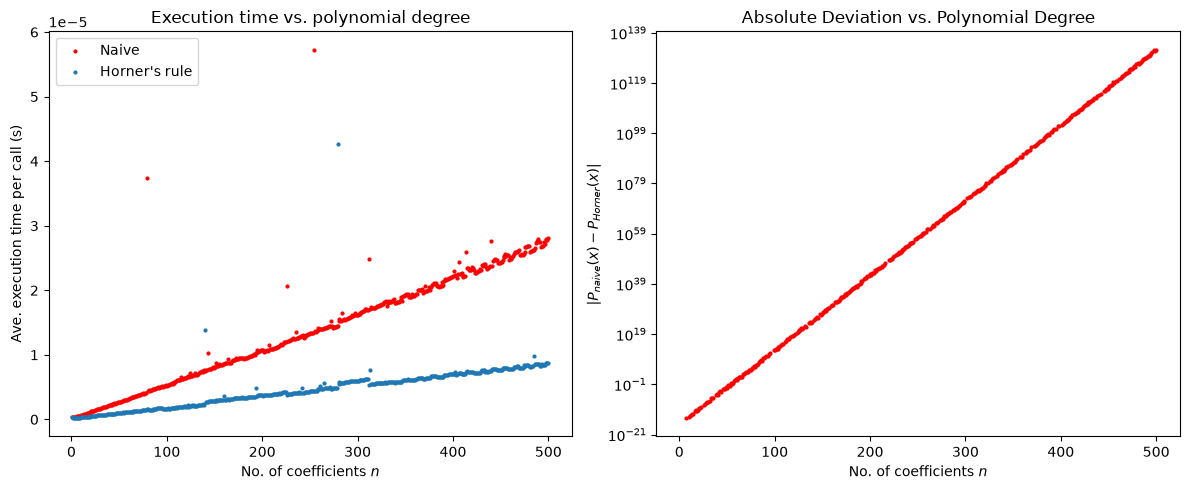

In [40]:
# code here

import time
import matplotlib.pyplot as plt

# Configuration parameters
X_VAL = 2.0
DEGREES = range(1, 501)
RUNS_PER_DEGREE = 10


def time_execution(func, coefficients, x_point, trials):
    # this is to measure average execution time per call and returns the computed result
    start = time.perf_counter()
    for _ in range(trials):
        val = func(coefficients, x_point)
    avg_time = (time.perf_counter() - start) / trials
    return val, avg_time


# Data collection
t_naive, t_horner, abs_diffs = [], [], []

for deg in DEGREES:
    # Fractional coefficients trigger floating-point rounding errors
    coeffs = [1.0 / (idx + 1) for idx in range(deg)]

    val_n, time_n = time_execution(naive_eval, coeffs, X_VAL, RUNS_PER_DEGREE)
    val_h, time_h = time_execution(horner_eval, coeffs, X_VAL, RUNS_PER_DEGREE)

    t_naive.append(time_n)
    t_horner.append(time_h)
    abs_diffs.append(abs(val_n - val_h))

fig, (ax_time, ax_diff) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax_time.scatter(DEGREES, t_naive, s=4, color="red", label="Naive")
ax_time.scatter(DEGREES, t_horner, s=4, color="tab:blue", label="Horner's rule")
ax_time.set_xlabel("No. of coefficients $n$")
ax_time.set_ylabel("Ave. execution time per call (s)")
ax_time.set_title("Execution time vs. polynomial degree")
ax_time.legend(loc="upper left")

# Plot 2
ax_diff.scatter(DEGREES, abs_diffs, s=4, color="red")
ax_diff.set_xlabel("No. of coefficients $n$")
ax_diff.set_ylabel(r"$|P_{naive}(x) - P_{Horner}(x)|$")
ax_diff.set_title("Absolute Deviation vs. Polynomial Degree")
ax_diff.set_yscale("log")

plt.tight_layout()
plt.savefig("E3_Problem1_1.png")
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

I made a code that compares naive left-to-right polynomial evaluation against Horner’s rule across degrees $n \in [1, 500]$ to demonstrate differences between the 2 methods. Coefficients ($p_k = 1 / (k + 1)$) were used to trigger small computer rounding errors, while average runtimes were measured to get clean, reliable speed comparisons. By working from right to left, Horner’s rule skips repeated multiplication steps, making it significantly faster and far more accurate than standard left-to-right calculations.

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

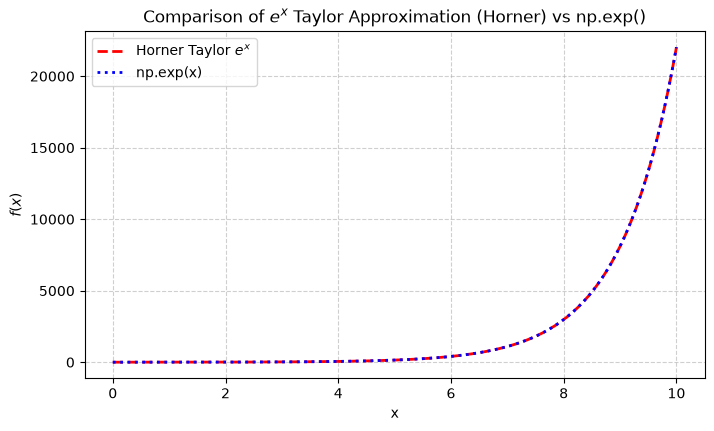

In [41]:
# code

import matplotlib.pyplot as plt
import numpy as np


def exp_taylor_horner(x, n=50):
    
    result = 0.0
    for k in range(n, 0, -1):
        result = (result + 1.0) * x / k
    return result + 1.0


# test points for x in [0, 10]
x_vals = np.linspace(0, 10, 200)

# evaluate using custom Horner function and np.exp
y_horner = [exp_taylor_horner(x) for x in x_vals]
y_np = np.exp(x_vals)

# Plot 
plt.figure(figsize=(8, 4.5))
plt.plot(x_vals, y_horner, "r--", linewidth=2, label="Horner Taylor $e^x$")
plt.plot(x_vals, y_np, "b:", linewidth=2, label="np.exp(x)")
plt.title("Comparison of $e^x$ Taylor Approximation (Horner) vs np.exp()")
plt.xlabel("x")
plt.ylabel("$f(x)$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("E3_Problem2_1.png")
plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

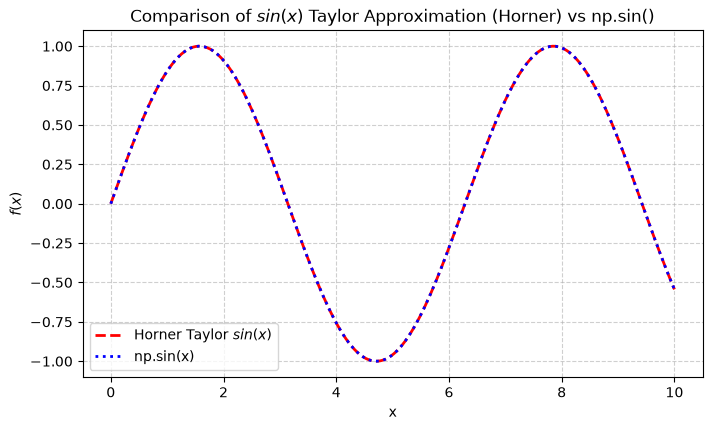

In [42]:
# code 

import matplotlib.pyplot as plt
import numpy as np


def sin_taylor_horner(x, n=30):
    y = x * x  # Single multiplication; avoids evaluating exponents
    result = 0.0
    for k in range(n, 0, -1):
        result = 1.0 - y * result / ((2 * k) * (2 * k + 1))
    return x * result


# Generate test points for x in [0, 10]
x_vals = np.linspace(0, 10, 200)

# Evaluate using custom Horner function and np.sin
y_horner = [sin_taylor_horner(x) for x in x_vals]
y_np = np.sin(x_vals)

# Plot comparison
plt.figure(figsize=(8, 4.5))
plt.plot(x_vals, y_horner, "r--", linewidth=2, label="Horner Taylor $sin(x)$")
plt.plot(x_vals, y_np, "b:", linewidth=2, label="np.sin(x)")
plt.title("Comparison of $sin(x)$ Taylor Approximation (Horner) vs np.sin()")
plt.xlabel("x")
plt.ylabel("$f(x)$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("E3_Problem2_2.png")
plt.show()



#### Problem 2 code summary

This code evaluates the Taylor series for $e^x$ and $\sin(x)$ using Horner's rule to achieve high accuracy without relying on math libraries for function evaluation. By rewriting $\sin(x)$ as $x \cdot P(x^2)$ and nesting polynomial multiplications from right to left, the implementation completely eliminates explicit exponentiation (**) and reduces calculations to simple floating-point multiplications and additions. This design minimizes cumulative rounding error and matches NumPy's built-in reference functions across $x \in [0, 10]$.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

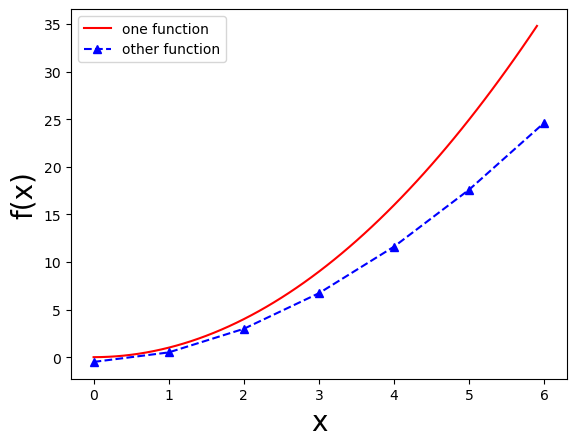

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

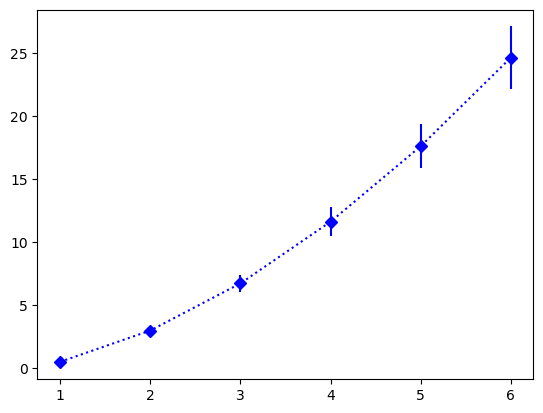

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])